In [3]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
from histpy import Histogram
%matplotlib inline
import healpy as hp

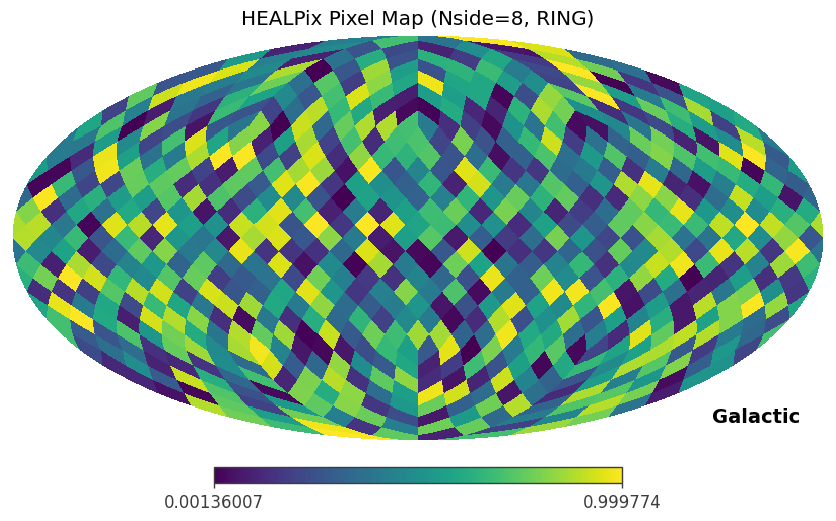

In [218]:
# Set HEALPix parameters
nside = 8  # Resolution parameter
npix = hp.nside2npix(nside)  # Compute the number of pixels (should be 768)
assert npix == 768, "Npix does not match the expected value!"

# Create a pixel map with random values (for demonstration)
pixel_map = np.random.rand(npix)  # Assign a random value to each pixel

# Plot the HEALPix map in the RING scheme
hp.mollview(pixel_map, title="HEALPix Pixel Map (Nside=8, RING)", coord=['G'], nest=False)
plt.show()

Find the pixel in the location of the source

In [233]:
# HEALPix parameters
nside = 8  # Given resolution
npix = hp.nside2npix(nside)  # Total pixels (should be 768)

# Define Galactic coordinate box (in degrees)
# Locatation of NGC4151 in galactic coordinates
l_min, l_max = 155.077 - 1, 155.077 + 1
b_min, b_max = 75.063 - 1, 75.063 + 1

# Convert Galactic (l, b) to HEALPix theta (colatitude) and phi (longitude)
l_vals = np.linspace(l_min, l_max, 10)  # Sample points within the range
b_vals = np.linspace(b_min, b_max, 10)

# Convert (l, b) to (theta, phi)
pixels = set()
for l in l_vals:
    for b in b_vals:
        theta = np.radians(90 - b)  # Convert latitude to colatitude
        phi = np.radians(l)         # Longitude remains unchanged
        pix = hp.ang2pix(nside, theta, phi, nest=False)  # Get pixel index
        pixels.add(pix)  # Store unique pixels

# Output the pixel numbers
pixel_list = sorted(pixels)
print("Pixels in the given range:", pixel_list)

Pixels in the given range: [7]


Slicing Method Attempt

In [180]:
NGC4151ec200 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux.hdf5")
NGC4151ec1000 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_COSI_sourceInj_correctFlux.hdf5")
background = Histogram.open("/Users/parshad/Software/cosipyFiles/DC2/bkg_binned_data.hdf5")
dc2Background = Histogram.open("/Users/parshad/Software/cosipyFiles/DC2/total_bg_3months_binned_for_continuum.hdf5")
dc3Background = Histogram.open("/Users/parshad/Software/cosipyFiles/DC3/Total_BG_3months_binned_for_continuum_filtered_with_SAAcut.hdf5")
# background = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/total_bg_3months_binned_for_continuum.hdf5")

In [180]:
NGC4151ec200.axes.labels

array(['Em', 'Phi', 'PsiChi'], dtype='<U6')

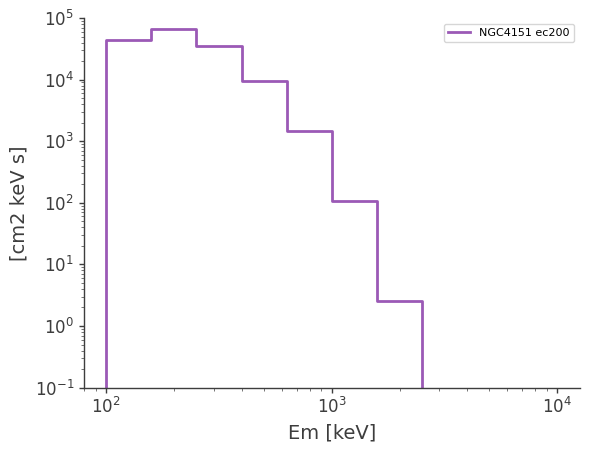

In [181]:
ax,plot = NGC4151ec200.project("Em").plot(label="NGC4151 ec200")
# (background.project("Em")).plot(ax, label="Bakcground")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-1, 1e5)
ax.legend()

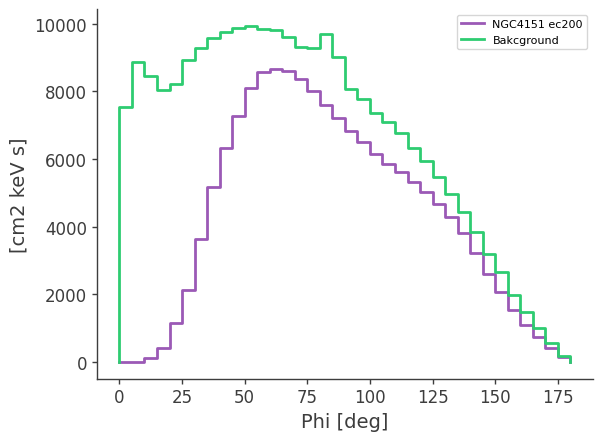

In [182]:
ax,plot = NGC4151ec200.project("Phi").plot(label="NGC4151 ec200")
(background.project("Phi")*5e-3).plot(ax, label="Bakcground")
ax.legend()

Text(0.5, 1.0, 'Phi bin 10 (50 degrees); NGC4151ec200')

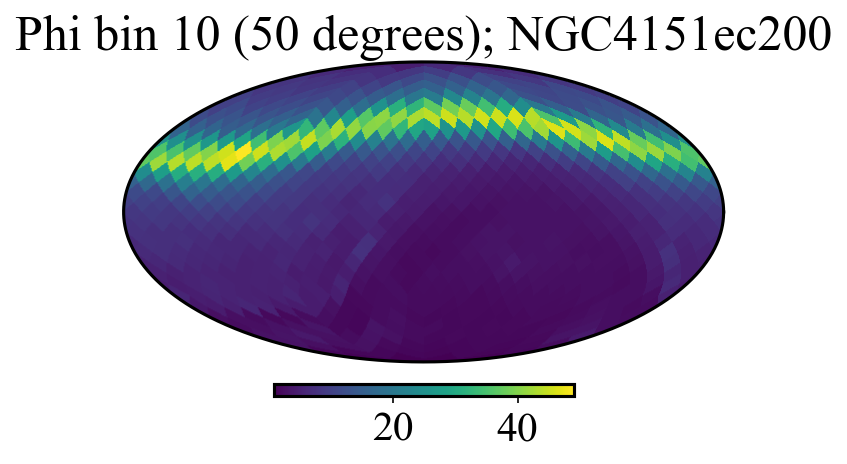

In [62]:
plot, ax = NGC4151ec200.slice[:, 10, :].project('PsiChi').plot(ax_kw = {'coord':'G'})
# plot, ax = NGC4151ec200.slice[:, 2, :].project('PsiChi').plot(ax_kw = {'coord':'G'})
# plot, ax = NGC4151ec200.project('PsiChi').plot(ax_kw = {'coord':'G'})
ax.get_figure().set_figwidth(4)
ax.get_figure().set_figheight(3)
plt.title("Phi bin 10 (50 degrees); NGC4151ec200")

# plot, ax = background.slice[:, :, :, 7].project('PsiChi').plot(ax_kw = {'coord':'G'})
# ax.get_figure().set_figwidth(4)
# ax.get_figure().set_figheight(3)
# plt.title("PsiChi Binning (counts); Background")


Make background the same units as source

In [181]:
dc2Background = dc2Background.project(['Em', 'Phi', 'PsiChi'])
dc3Background = dc3Background.project(['Em', 'Phi', 'PsiChi'])
NGC4151ec200 = NGC4151ec200.to(unit = dc2Background.unit, update = False)
NGC4151ec1000 = NGC4151ec1000.to(unit = dc2Background.unit, update = False)

In [182]:
# Step 1: Slice and project dc2Background on "Em"
# dc2_proj = dc2Background.slice[:, :, 7].project("Em")
dc3_proj = dc3Background.slice[:, :, 7].project("Em")

# Step 2: Project NGC4151ec200 on "Em"
ngc_proj_ec200 = NGC4151ec200.project("Em")
ngc_proj_ec1000 = NGC4151ec1000.project("Em")

# Step 3: Extract bin contents (1D NumPy arrays)
dc3_values = dc3_proj.contents.todense()
ngc_values_ec200 = ngc_proj_ec200.contents
ngc_values_ec1000 = ngc_proj_ec1000.contents

em_bins = dc3_proj.axes["Em"].edges
em_bins = em_bins[:-1]

total_values_ec200 = dc3_values + ngc_values_ec200
total_values_ec1000 = dc3_values + ngc_values_ec1000

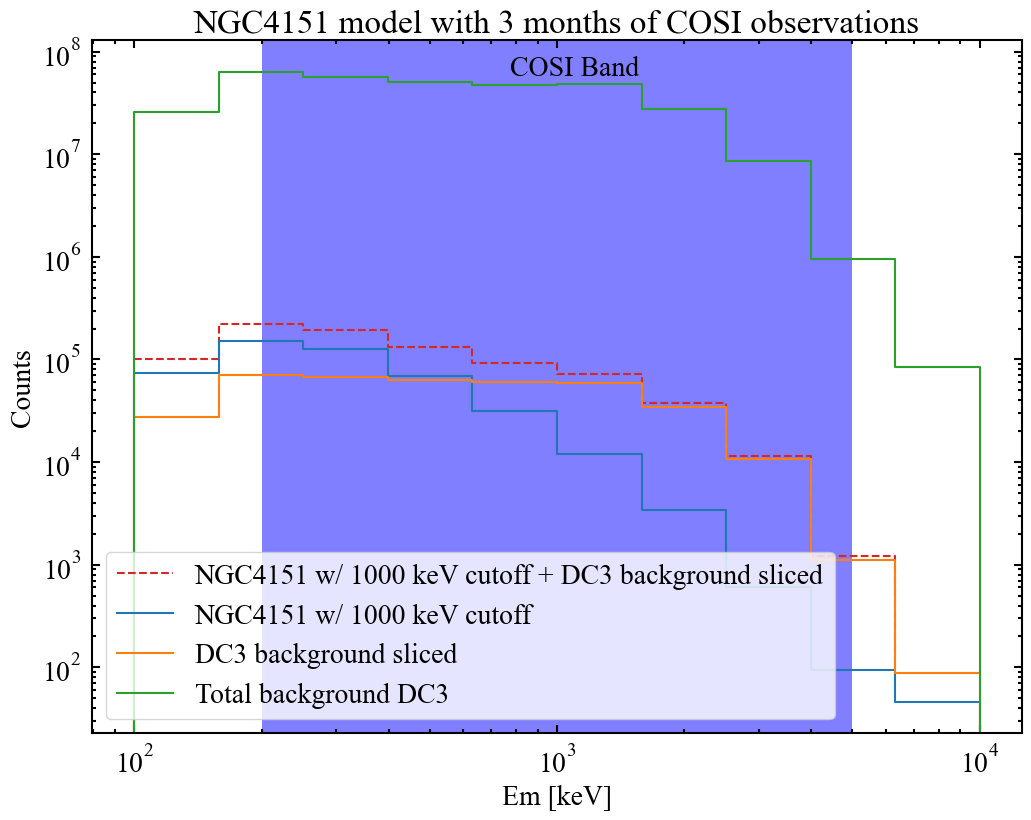

In [ ]:
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

plot, ax = plt.subplots(figsize=(12, 9))

NGC4151ec200.project("Em").draw(ax, label="NGC4151 w/ 200 keV cutoff")
# NGC4151ec1000.project("Em").draw(ax, label="NGC4151 w/ 1000 keV cutoff")
# dc2Background.slice[:, :, 7].project("Em").draw(ax, linestyle='--', label="DC2 background sliced")
dc3Background.slice[:, :, 7].project("Em").draw(ax, label="DC3 background sliced")
# dc2Background.project("Em").draw(ax, label="Total background DC2")
dc3Background.project("Em").draw(ax, label="Total background DC3")
ax.step(em_bins, total_values_ec200, where='post', linestyle='--', label="NGC4151 w/ 200 keV cutoff + DC3 background sliced")
# ax.step(em_bins, total_values_ec1000, where='post', linestyle='--', label="NGC4151 w/ 1000 keV cutoff + DC3 background sliced")

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=20,  loc='lower left')
ax.set_ylabel("Counts")
# ax.set_xlim(1e2, 5e3)
# ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.45, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC4151 model with 3 months of COSI observations")
# ax.set_title("Crab model with 3 months of COSI observations")
plt.show()

DC3 Data

In [66]:
DC3NGC4151_ec200 = Histogram.open("/Users/parshad/Software/cosipyFiles/DC3/NGC_4151_EC200_3months_unbinned_data_filtered_with_SAAcut_binned.hdf5")

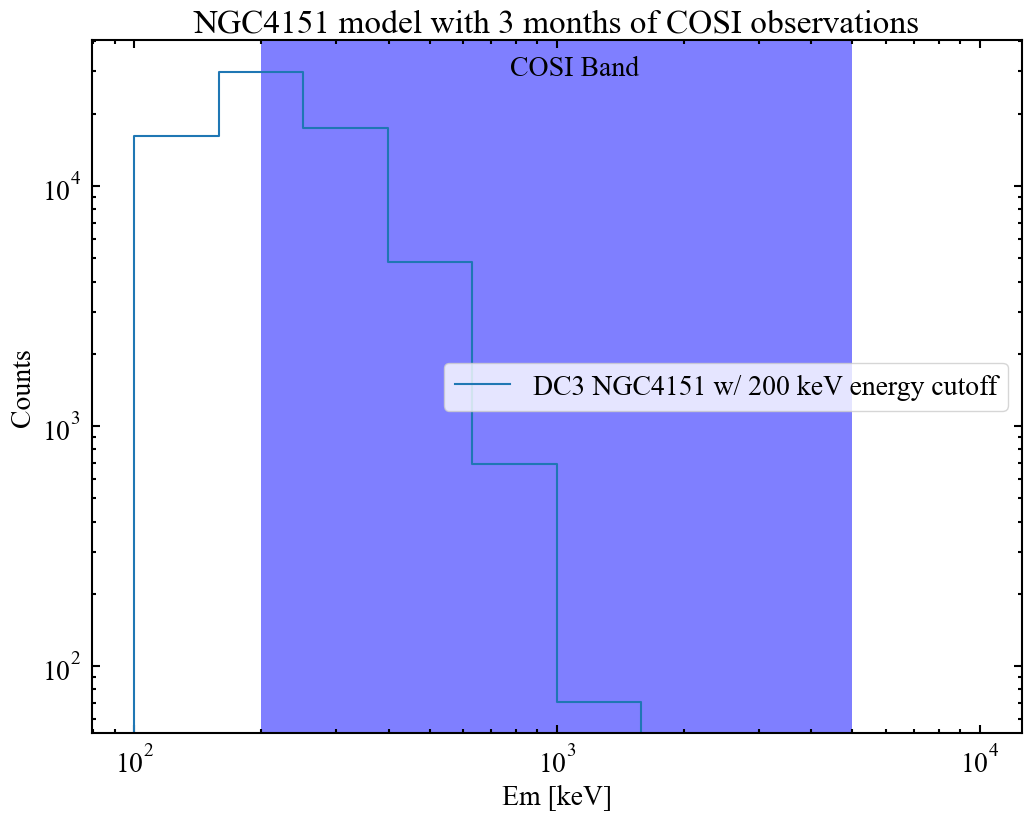

In [73]:
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

plot, ax = plt.subplots(figsize=(12, 9))

DC3NGC4151_ec200.project("Em").plot(ax, label="DC3 NGC4151 w/ 200 keV energy cutoff")

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")
# ax.set_xlim(1e2, 5e3)
# ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.45, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC4151 model with 3 months of COSI observations")
ax.legend(fontsize=20,  loc='center right')
# ax.set_title("Crab model with 3 months of COSI observations")
plt.show()